# Weathering mediated bedrock erosion: Simulation

### Preliminaries

In [1]:
import wmbe, sympy as sy, numpy as np
# from matplotlib.pylab import plt
sy.init_printing(pretty_print=True,wrap_line=True)
from sympy import Eq
from wmbe.symbols import *

/Users/cps/Projects/WMBE/src/wmbe/plot.py:757: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel("Erosion rate  $\\nu_\mathsf{{s}}$  [-]")


For so-called weathering (supply) limitation, $W \ll 1/4$:

\begin{equation}
    \lim_{W\rightarrow\infty} \nu_s \approx 1+W
    \quad\Leftrightarrow\quad
    v_s \approx  v_0 + \frac{w_0}{k}
\end{equation}

For so-called erosion limitation (unlimited supply), $W \gg 2.5$:

\begin{equation}
    \lim_{W\rightarrow\infty} \nu_s \approx \dfrac{1}{2}+ \sqrt{W}
    \quad\Leftrightarrow\quad
    v_s \approx \dfrac{1}{2}+\sqrt{\frac{w_0 v_0}{k}}
\end{equation}



## Numerical integration

In [2]:
em = wmbe.theory.WeatheringMediatedErosion()

### High $W$

In [3]:
pdict = {
    w_0: np.float64(100),
    v_0: np.float64(10),
    k:   np.float64(1)
}
ndict = {
    chi_domain_size: 20.0,
    tau_domain_size: 80.0,
    Delta_chi      : 0.005,
    Delta_tau      : 0.005
}
ew_highW = wmbe.solve1d.ErosionWeathering(pdict,ndict)
ew_highW.ndict
ew_highW.solve()
ew_highW.pdict

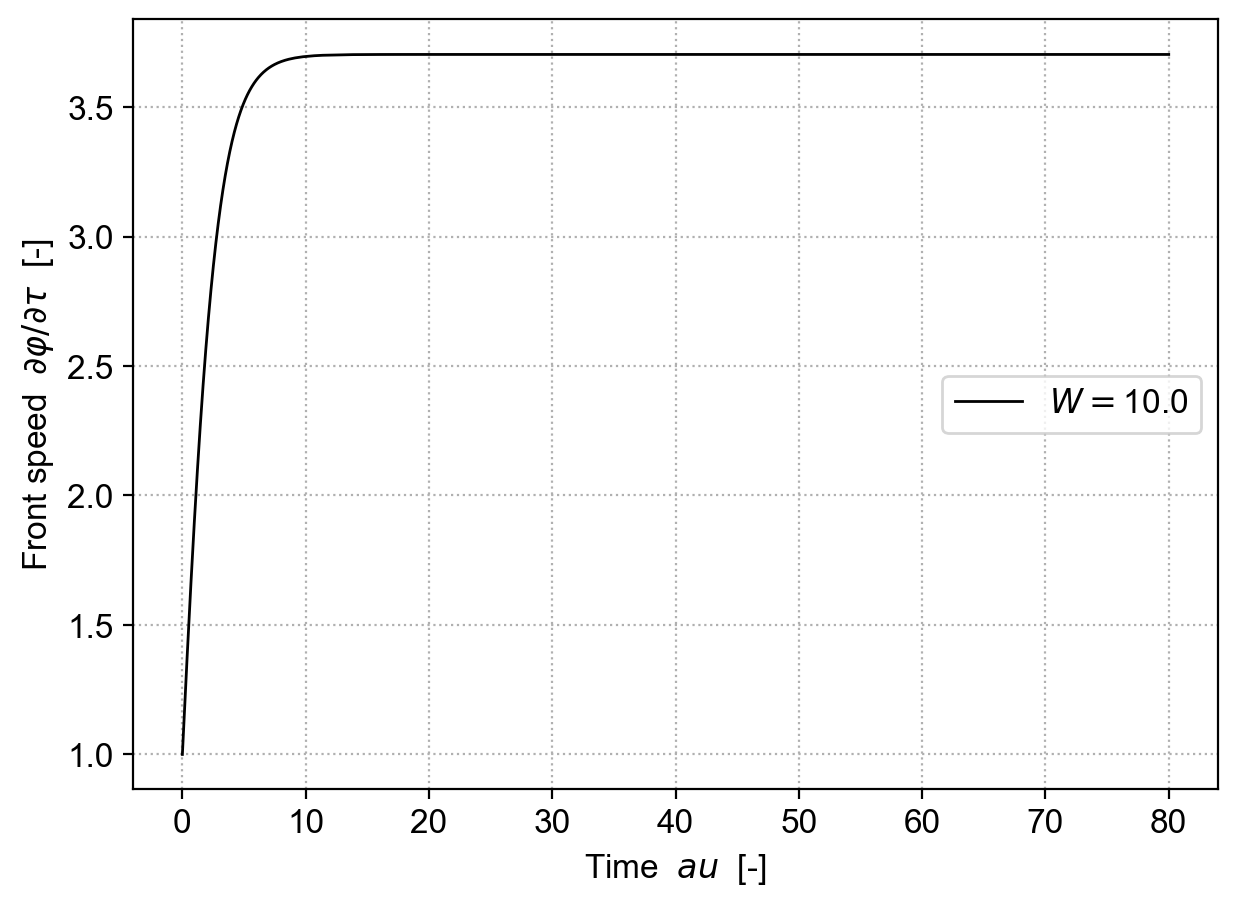

In [4]:
fig_nu_evolution_highW = wmbe.plot.create_figure("highW_nu_evolution")
wmbe.plot.plot_nu_evolution(fig_nu_evolution_highW,ew_highW)

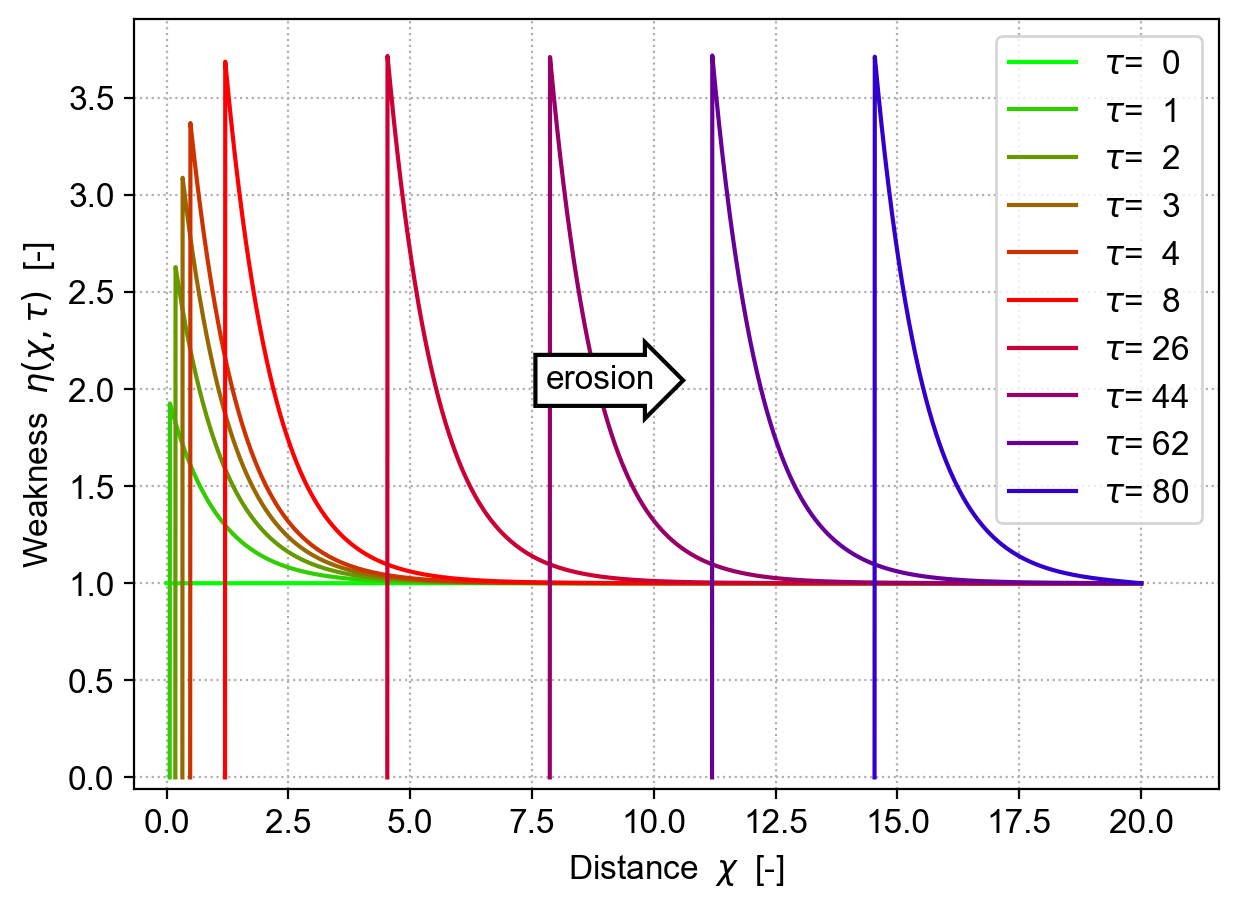

In [5]:
fig_eta_evolution_highW = wmbe.plot.create_figure("highW_eta_evolution")
wmbe.plot.plot_eta_evolution(fig_eta_evolution_highW, ew_highW,tc=20,nd=0)

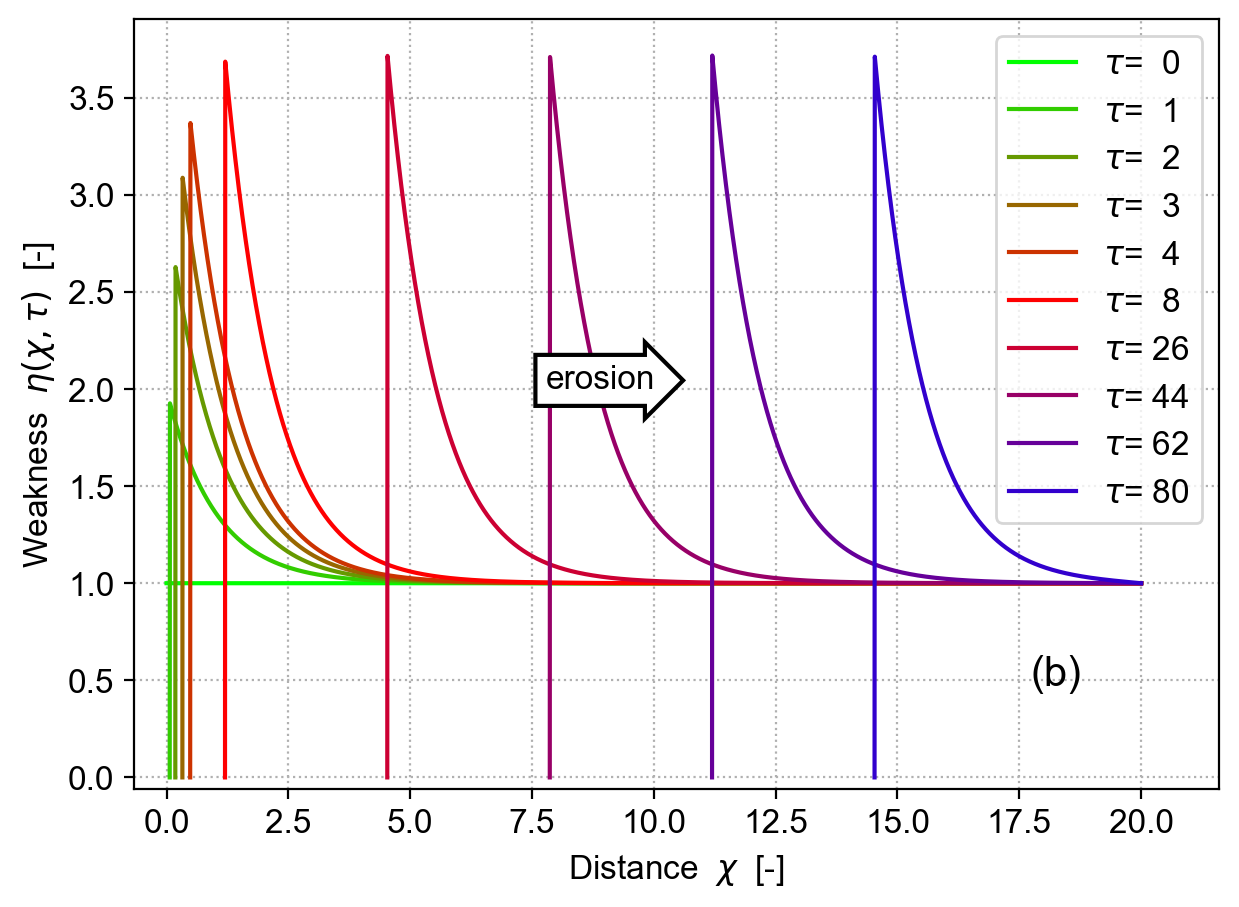

In [6]:
fig_eta_evolution_highW \
    = wmbe.plot.create_figure("highW_eta_evolution_subfigb")
wmbe.plot.plot_eta_evolution(fig_eta_evolution_highW, 
                            ew_highW,tc=20,nd=0, 
                            text_label=((0.85,0.15),"(b)",15))

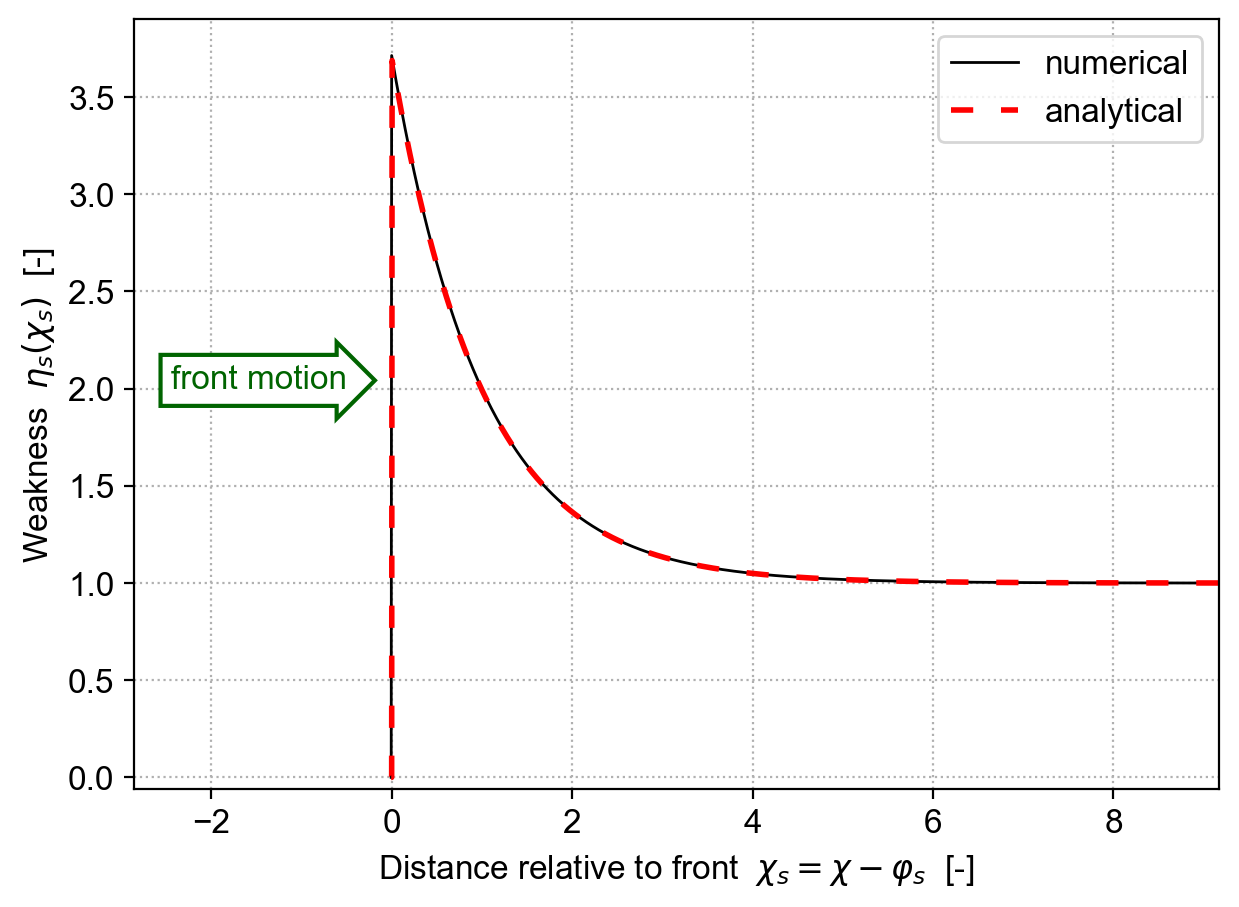

In [7]:
fig_etas_ss_highW = wmbe.plot.create_figure("highW_etas_ss")
wmbe.plot.plot_etas_steadystate(fig_etas_ss_highW,ew_highW)

### High transitional $W$

In [8]:
pdict = {
    w_0: np.float64(25),
    v_0: np.float64(10),
    k:   np.float64(1)
}
ndict = {
    chi_domain_size: 20.0,
    tau_domain_size: 80.0,
    Delta_chi      : 0.005,
    Delta_tau      : 0.005
}
ew_highTransW = wmbe.solve1d.ErosionWeathering(pdict,ndict)
ew_highTransW.ndict
ew_highTransW.solve()
ew_highTransW.pdict

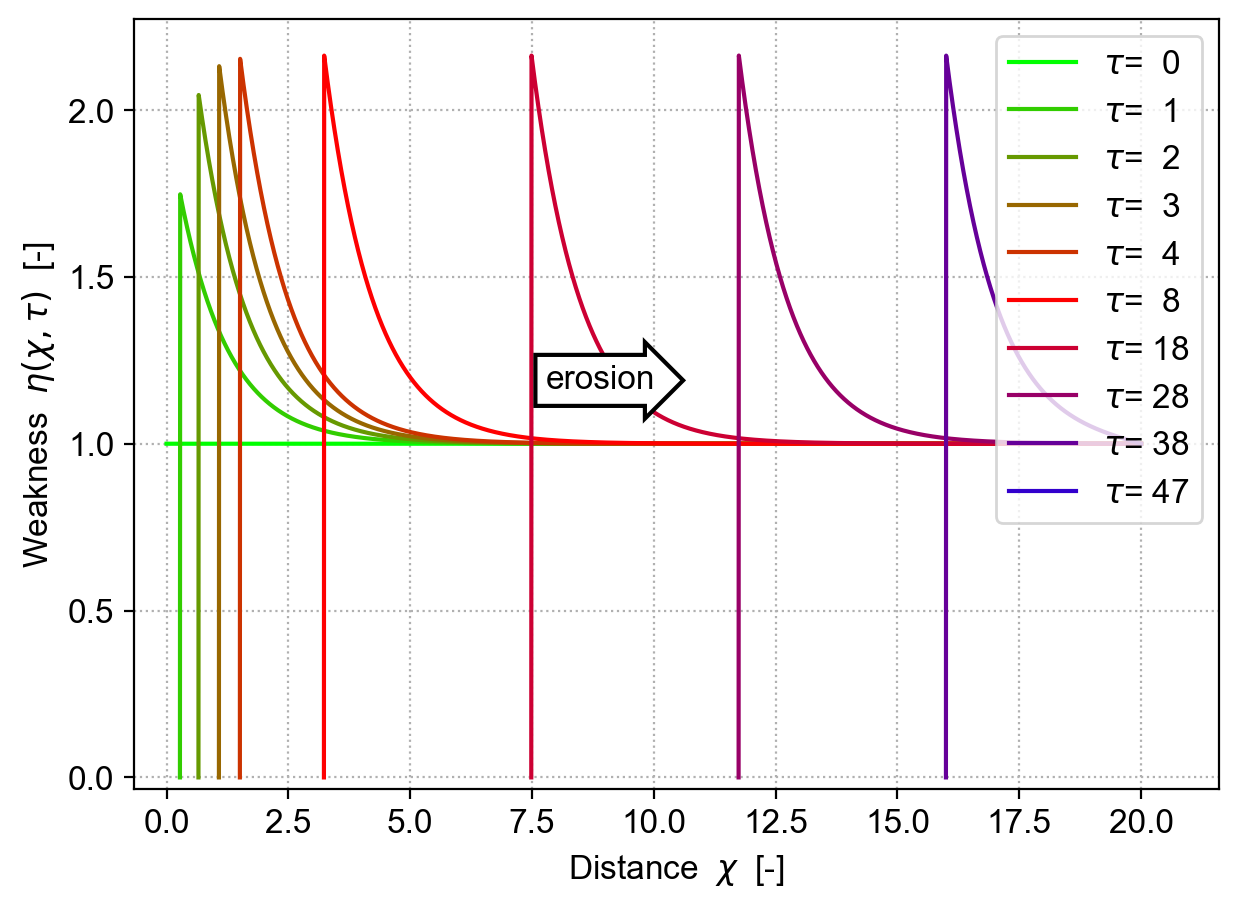

In [9]:
fig_eta_evolution_highTransW \
    = wmbe.plot.create_figure("highTransW_eta_evolution")
wmbe.plot.plot_eta_evolution(fig_eta_evolution_highTransW, ew_highTransW,
                        tc=20,nd=0)

### Low-transitional $W$

In [10]:
pdict = {
    w_0: np.float64(2.5),
    v_0: np.float64(10),
    k:   np.float64(1)
}
ndict = {
    chi_domain_size: 30.0,
    tau_domain_size: 10.0,
    Delta_chi      : 0.01,
    Delta_tau      : 0.003
}
ew_lowTransW = wmbe.solve1d.ErosionWeathering(pdict,ndict)
ew_lowTransW.ndict
ew_lowTransW.solve()
ew_lowTransW.pdict

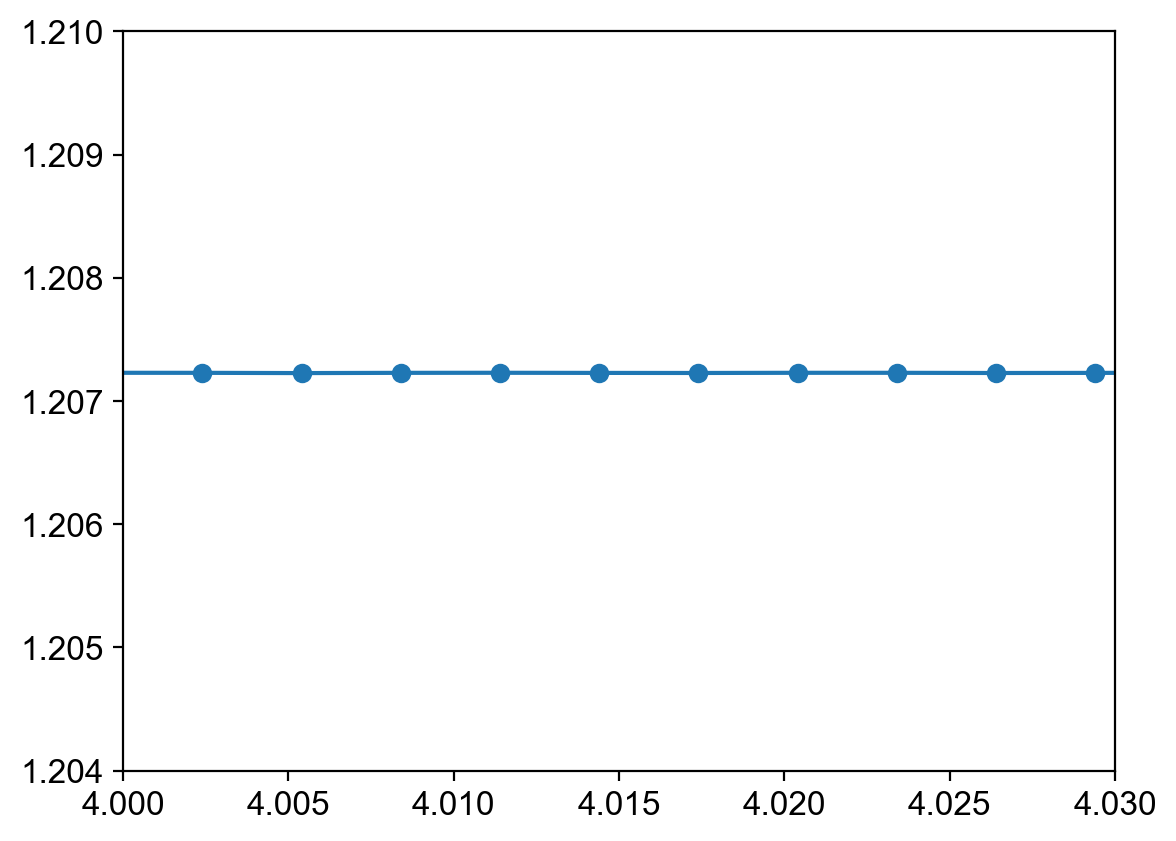

In [11]:
wmbe.plot.stability_check(ew_lowTransW.tau_array,ew_lowTransW.nu_array)

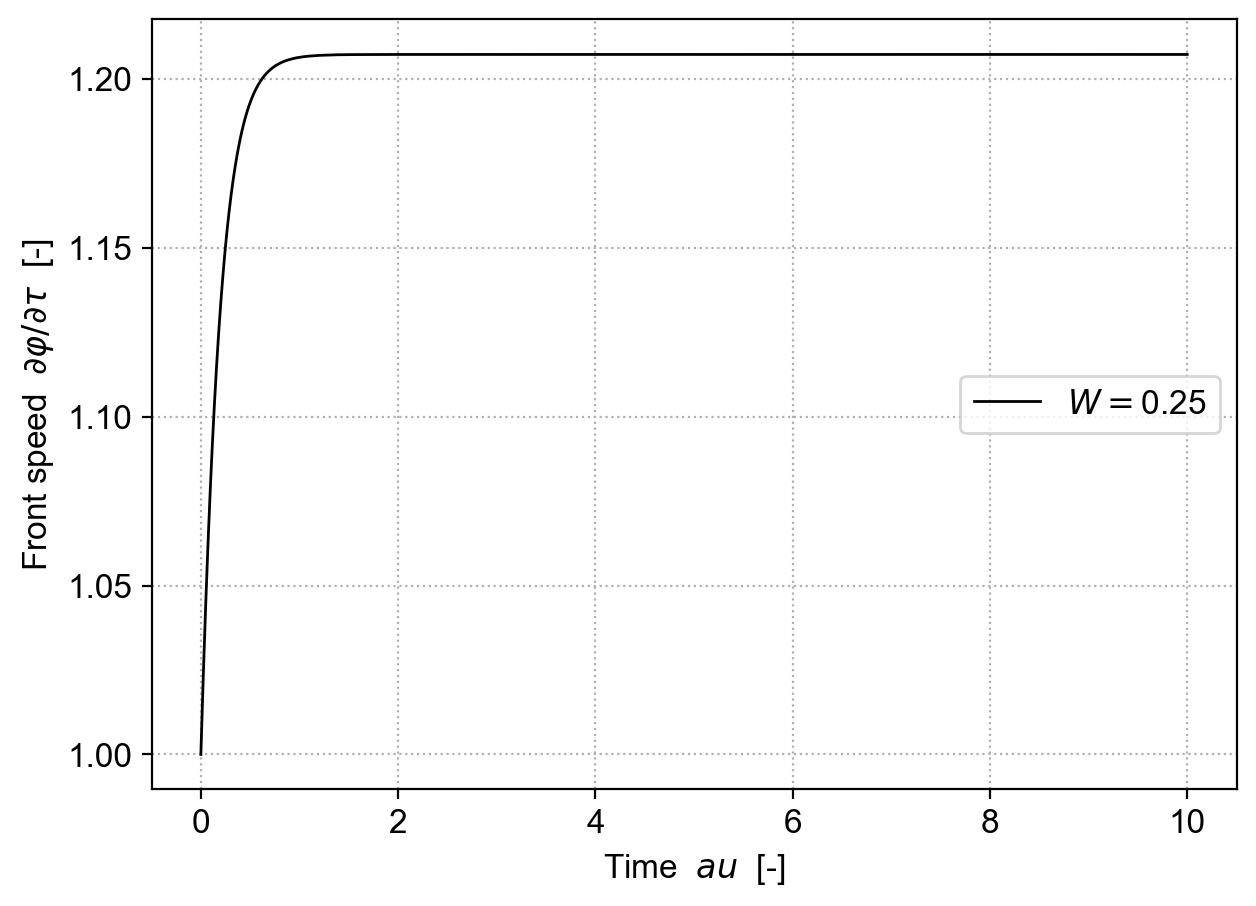

In [12]:
fig_nu_evolution_lowTransW \
    = wmbe.plot.create_figure("lowTransW_nu_evolution")
wmbe.plot.plot_nu_evolution(fig_nu_evolution_lowTransW,ew_lowTransW)

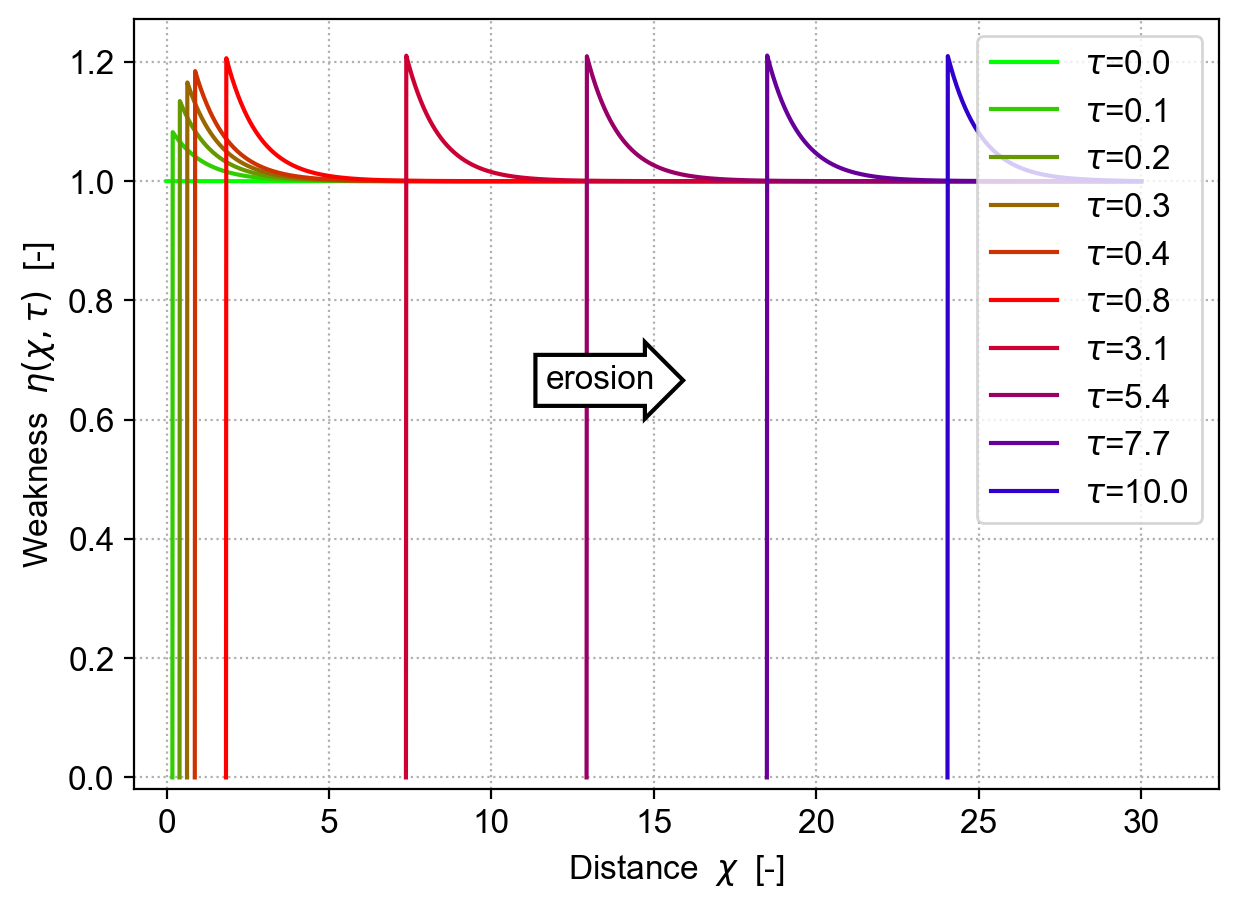

In [13]:
fig_eta_evolution_lowTransW \
    = wmbe.plot.create_figure("lowTransW_eta_evolution")
wmbe.plot.plot_eta_evolution(fig_eta_evolution_lowTransW, 
                            ew_lowTransW, tc=25, 
                            nd=1)

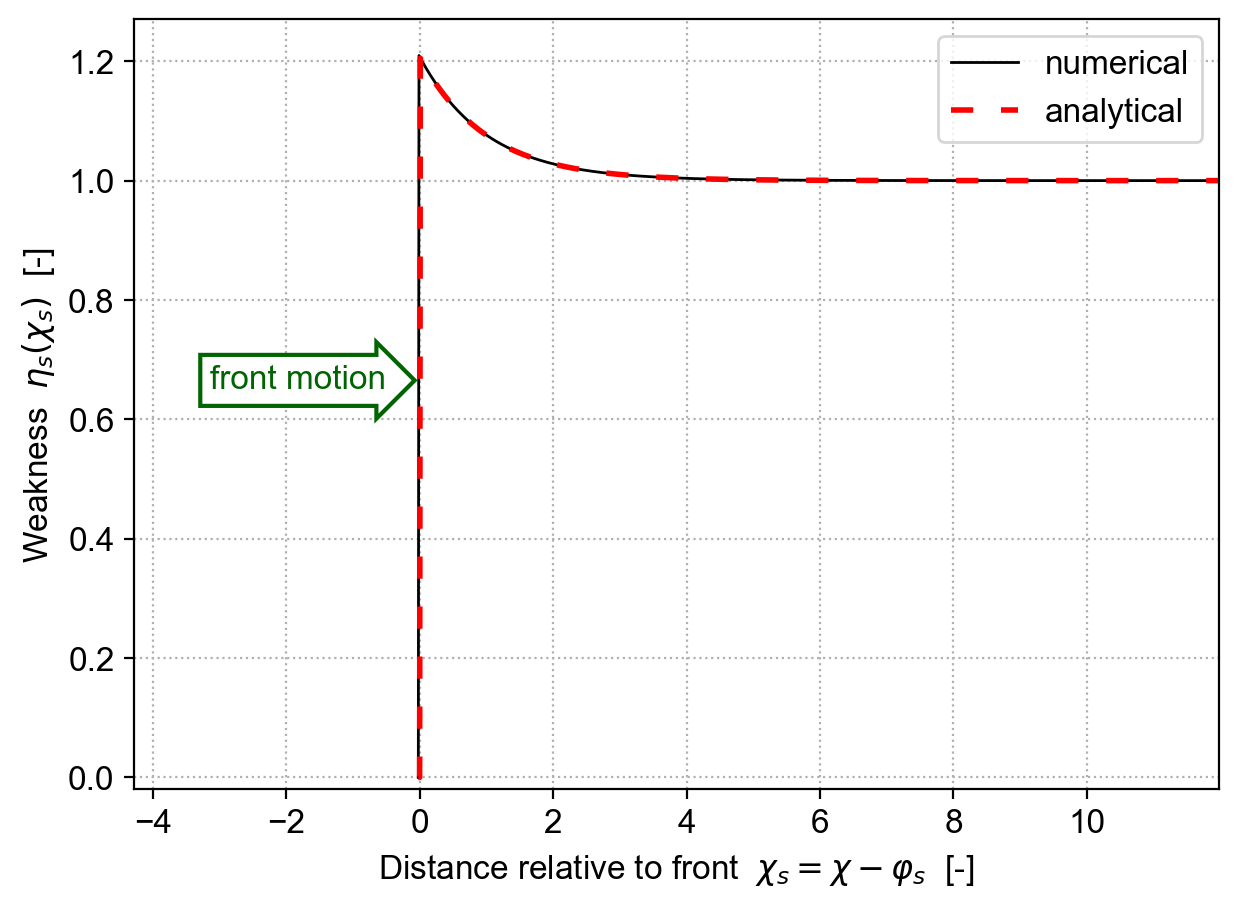

In [14]:
fig_etas_ss_lowTransW = wmbe.plot.create_figure("lowTransW_etas_ss")
wmbe.plot.plot_etas_steadystate(fig_etas_ss_lowTransW,ew_lowTransW)

### Low $W$

In [15]:
pdict = {
    w_0: np.float64(0.25),
    v_0: np.float64(10),
    k:   np.float64(1)
}
ndict = {
    chi_domain_size: 30.0,
    tau_domain_size: 1.0,
    Delta_chi      : 0.01,
    Delta_tau      : 0.0003
}
ew_lowW = wmbe.solve1d.ErosionWeathering(pdict,ndict)
ew_lowW.ndict
ew_lowW.solve()
ew_lowW.pdict

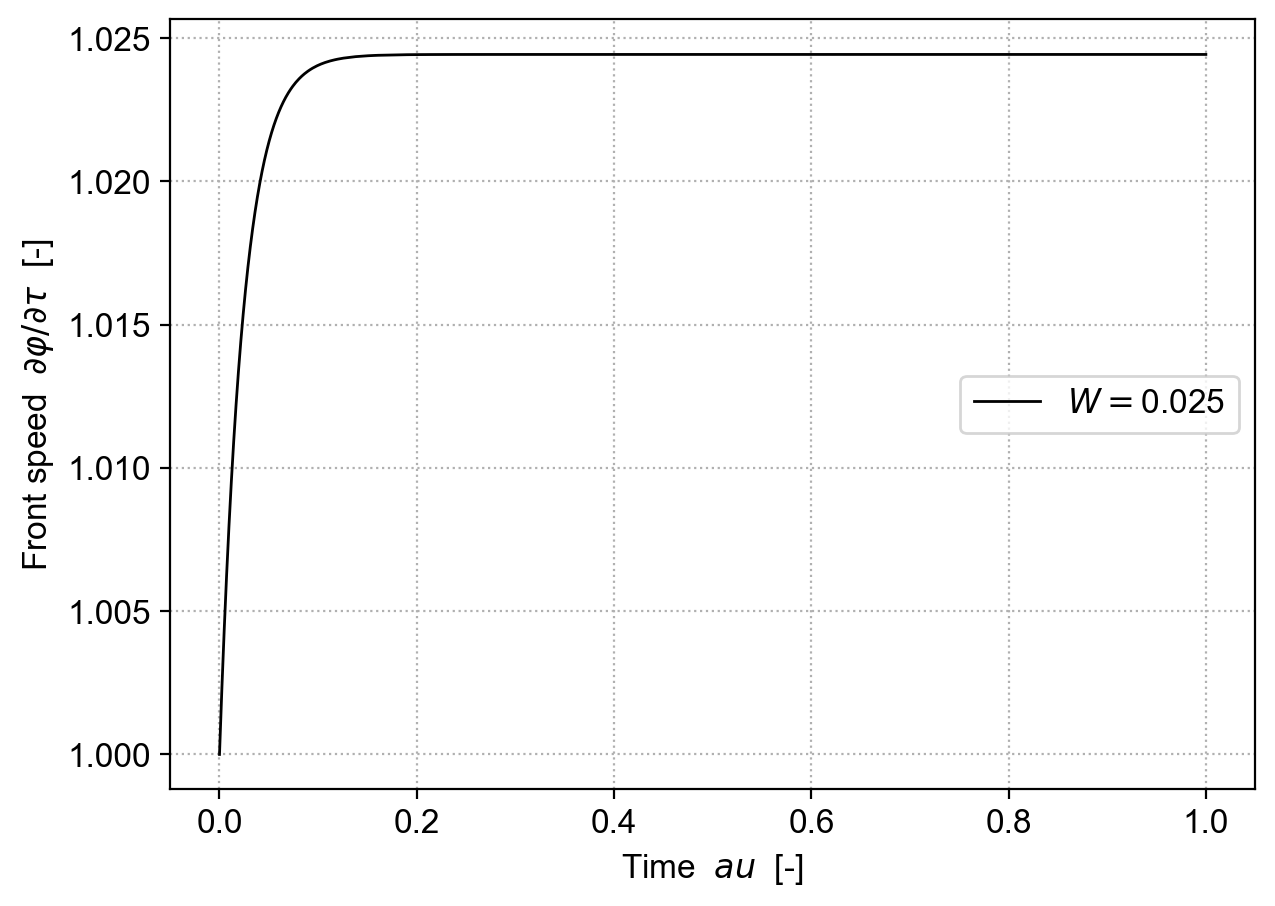

In [16]:
fig_nu_evolution_lowW = wmbe.plot.create_figure("lowW_nu_evolution")
wmbe.plot.plot_nu_evolution(fig_nu_evolution_lowW,ew_lowW)

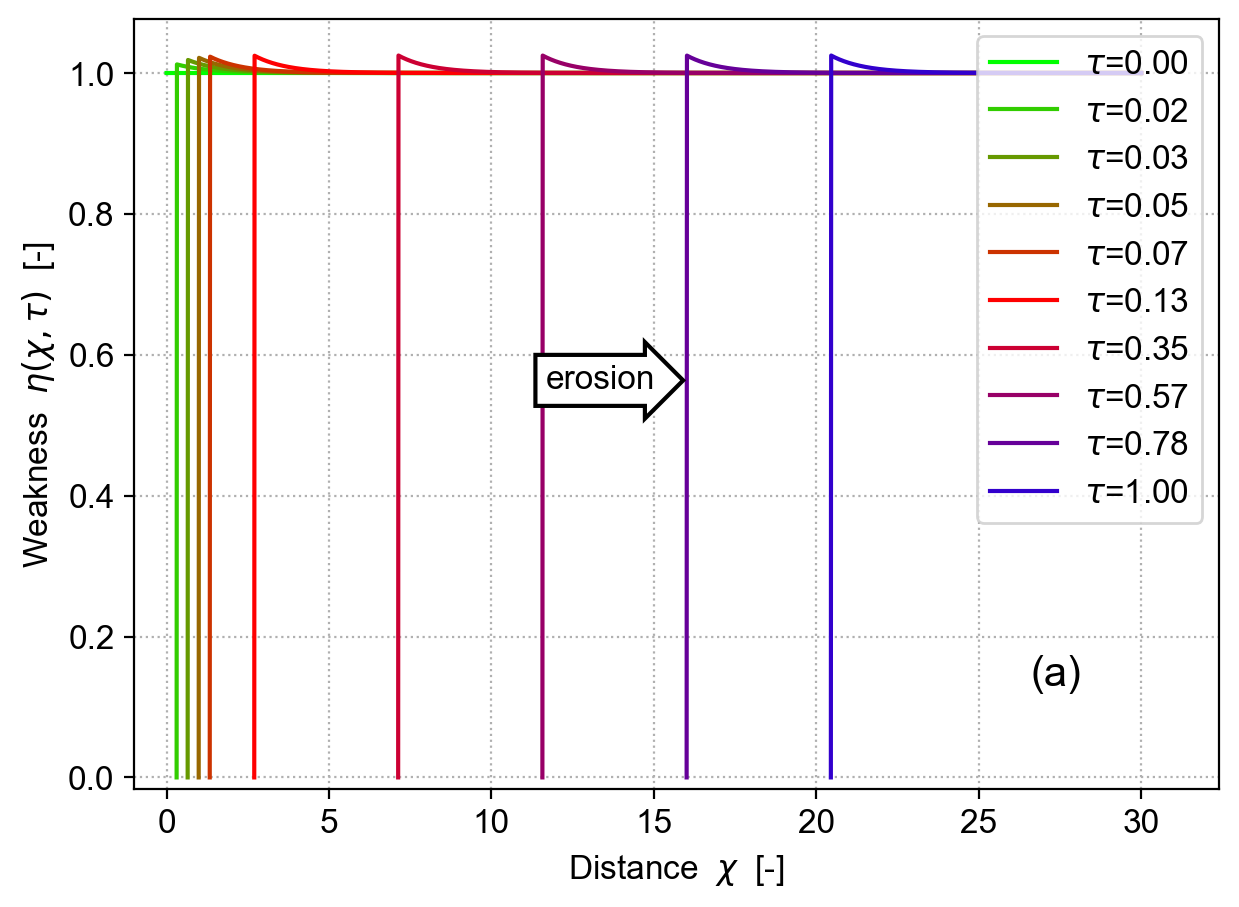

In [17]:
fig_eta_evolution_lowW \
    = wmbe.plot.create_figure("lowW_eta_evolution_subfiga")
wmbe.plot.plot_eta_evolution(fig_eta_evolution_lowW, ew_lowW, tc=15,  
                             text_label=((0.85,0.15),"(a)",15))

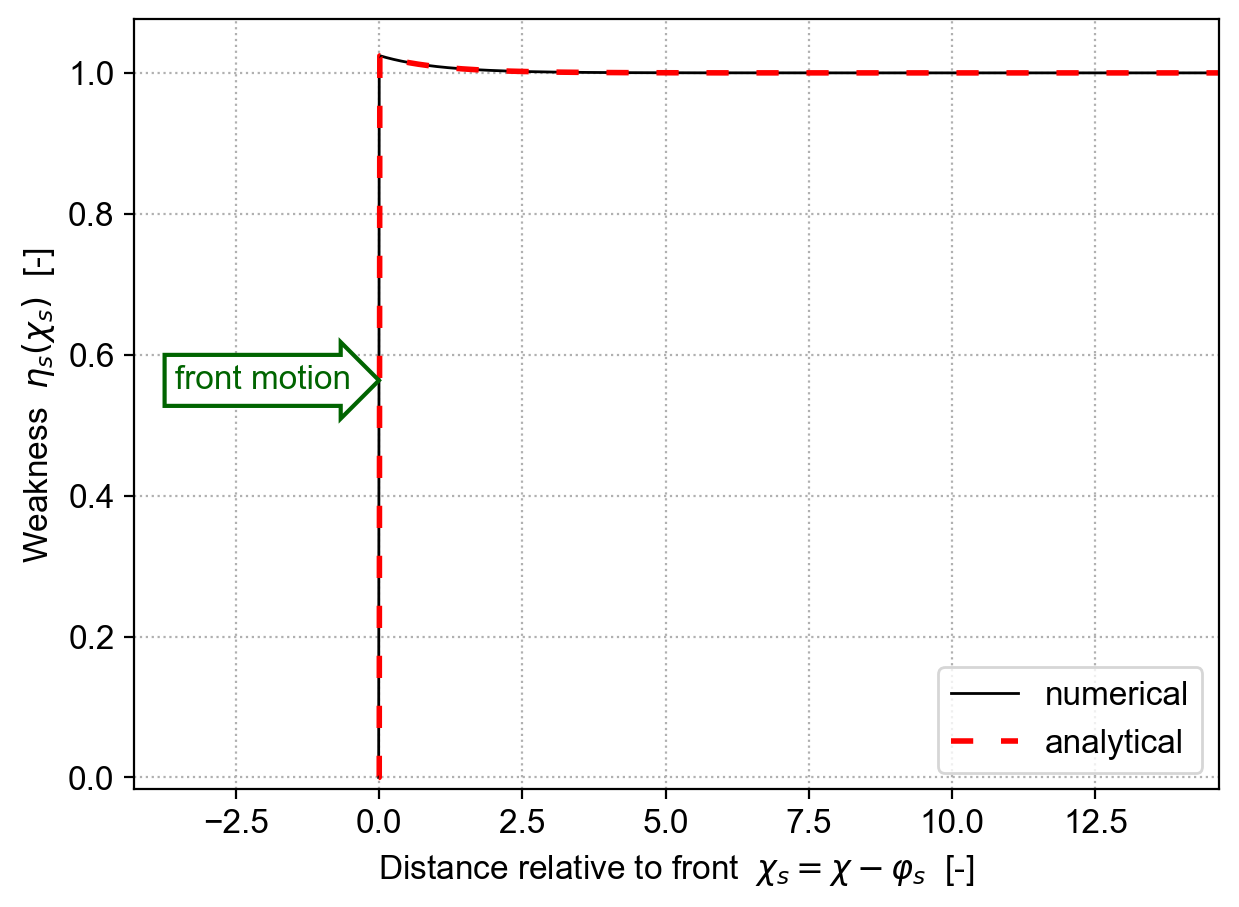

In [18]:
fig_etas_ss_lowW = wmbe.plot.create_figure("lowW_etas_ss")
wmbe.plot.plot_etas_steadystate(fig_etas_ss_lowW,ew_lowW)

### Comparison

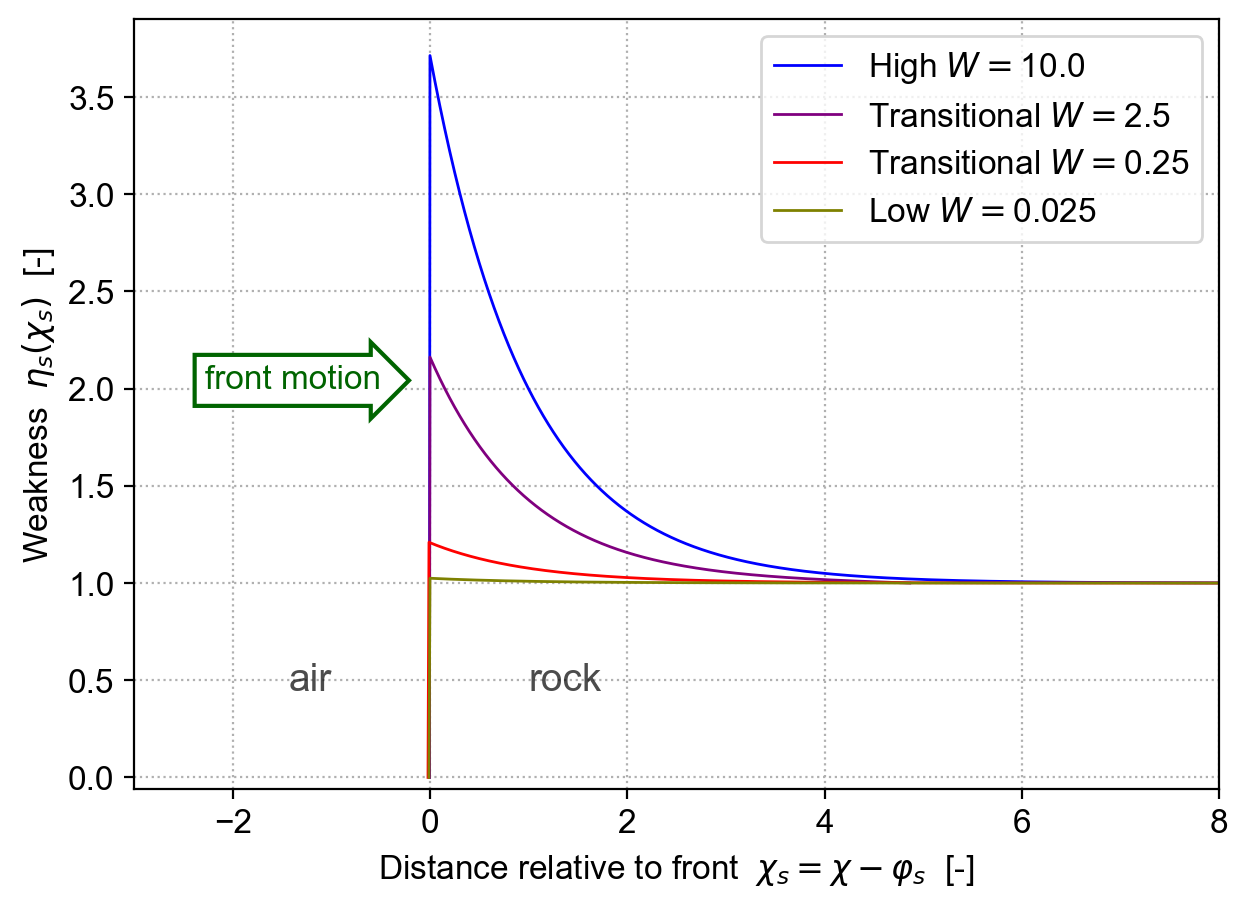

In [19]:
fig_etas_ss_setW = wmbe.plot.create_figure("etas_setW_ss")
wmbe.plot.plot_etas_steadystate_set(fig_etas_ss_setW, 
     [(ew_highW,"High $W=$"+str(ew_highW.pdict[W])),
      (ew_highTransW,"Transitional $W=$"+str(ew_highTransW.pdict[W])),
      (ew_lowTransW,"Transitional $W=$"+str(ew_lowTransW.pdict[W])),
      (ew_lowW,"Low $W=$"+str(ew_lowW.pdict[W]))])

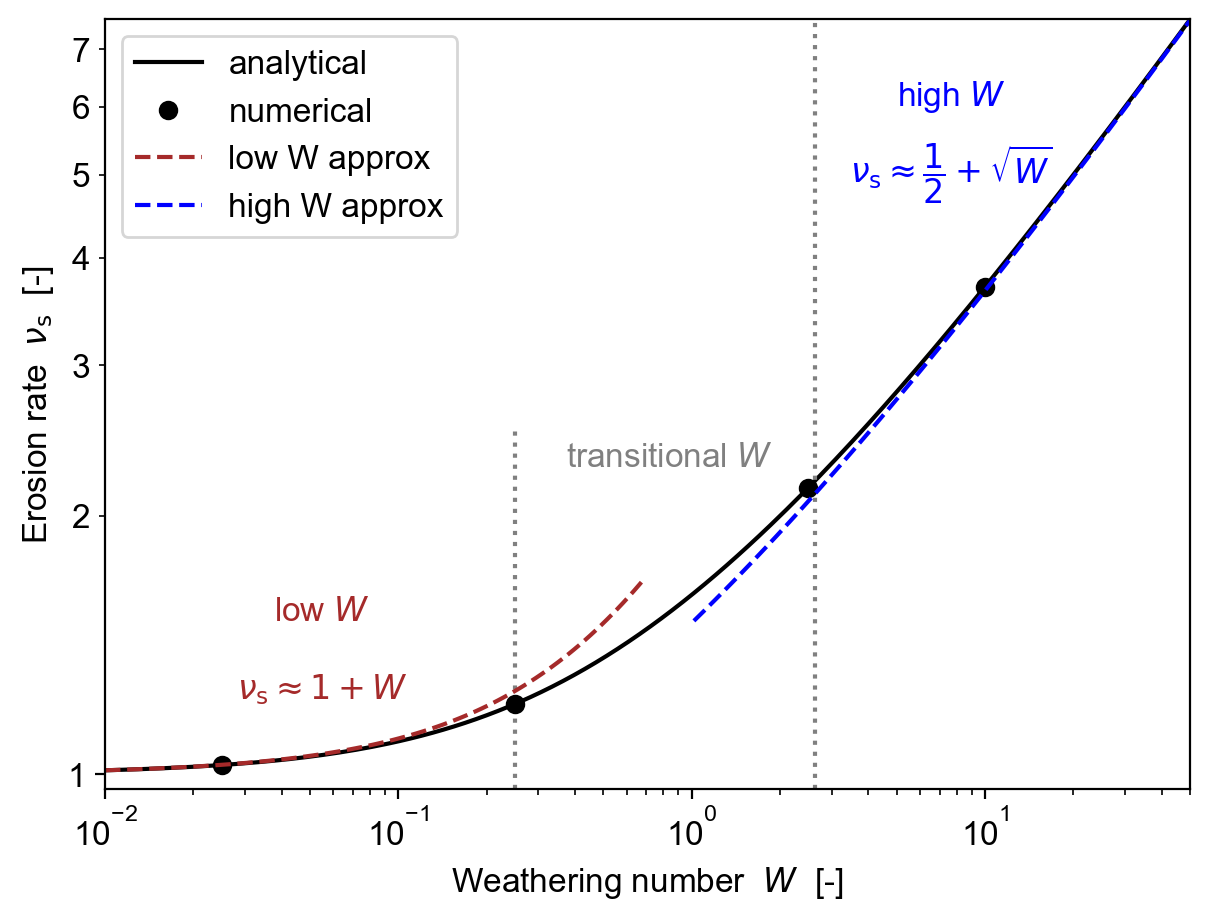

In [20]:
fig_nu_s = wmbe.plot.create_figure("nu_s")
em.nus_eqn_W
nus_solns_list = [ew_lowW,ew_lowTransW,ew_highTransW,ew_highW]
wmbe.plot.plot_nus_W(fig_nu_s, em, 
                    do_loglog=True, nus_solns_list=nus_solns_list)

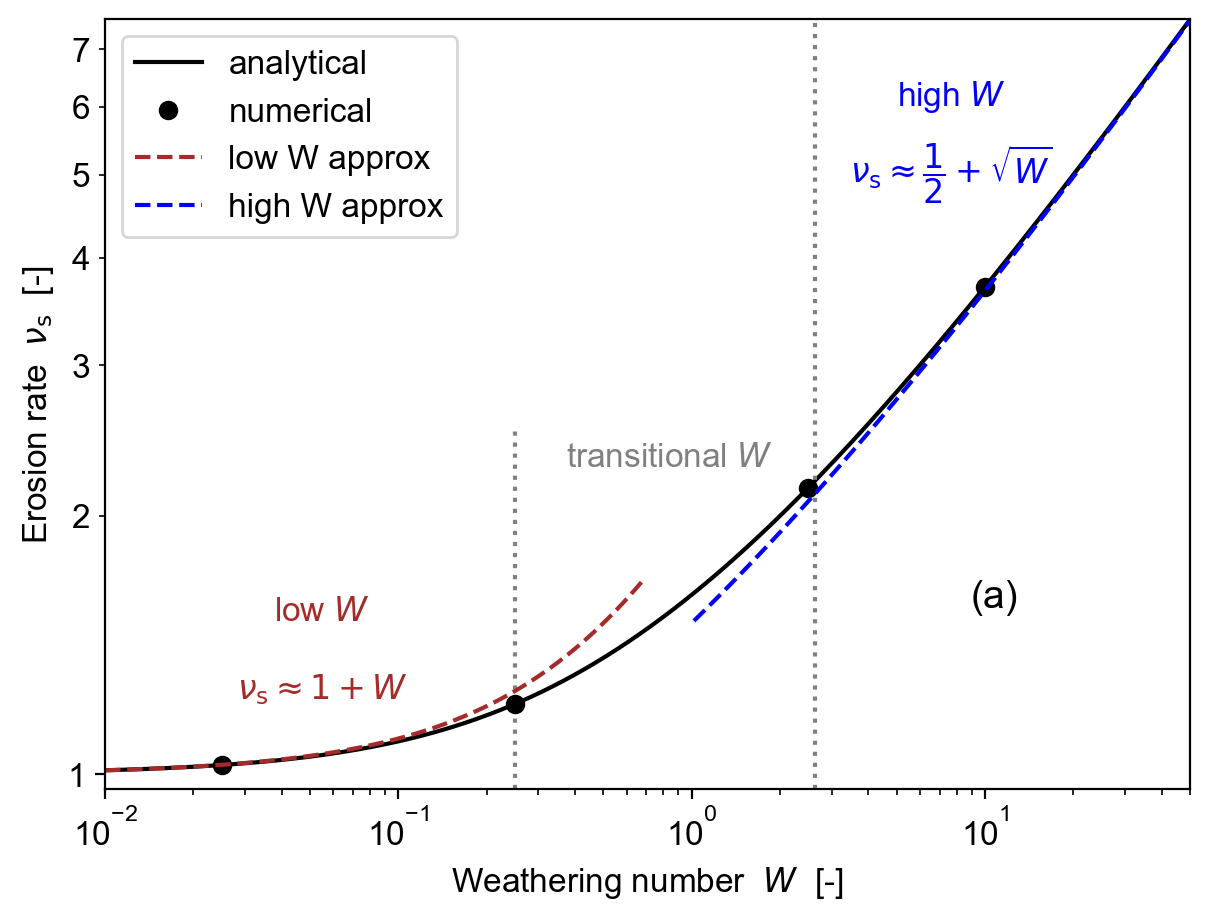

In [21]:
fig_nu_s_subfiga = wmbe.plot.create_figure("nu_s_subfiga")
nus_solns_list = [ew_lowW,ew_lowTransW,ew_highTransW,ew_highW]
wmbe.plot.plot_nus_W(fig_nu_s, em,
                    do_loglog=True, nus_solns_list=nus_solns_list, 
                    text_label="(a)")

In [22]:
nus_eqn = sy.Eq( nu_s, (1+sy.sqrt(1+4*W))/2 )
nus_lowW_eqn = sy.Eq( nu_s, 1+W )
nus_highW_eqn = sy.Eq( nu_s, ((sy.Rational(1,2)+sy.sqrt(W))) )
nus_lowW_eqn, nus_eqn, nus_highW_eqn
nus_lowW_error = (nus_lowW_eqn.rhs/nus_eqn.rhs)\
                    .subs({W:sy.Rational(1,4)}).simplify()

In [23]:
# sy.simplify( sy.Eq(nus_eqn.rhs,nus_highW_eqn.rhs*nus_lowW_error) )
# nus_highW_lim=sy.solve(_,W)[0]
# nus_highW_lim
# sy.N(nus_highW_lim)

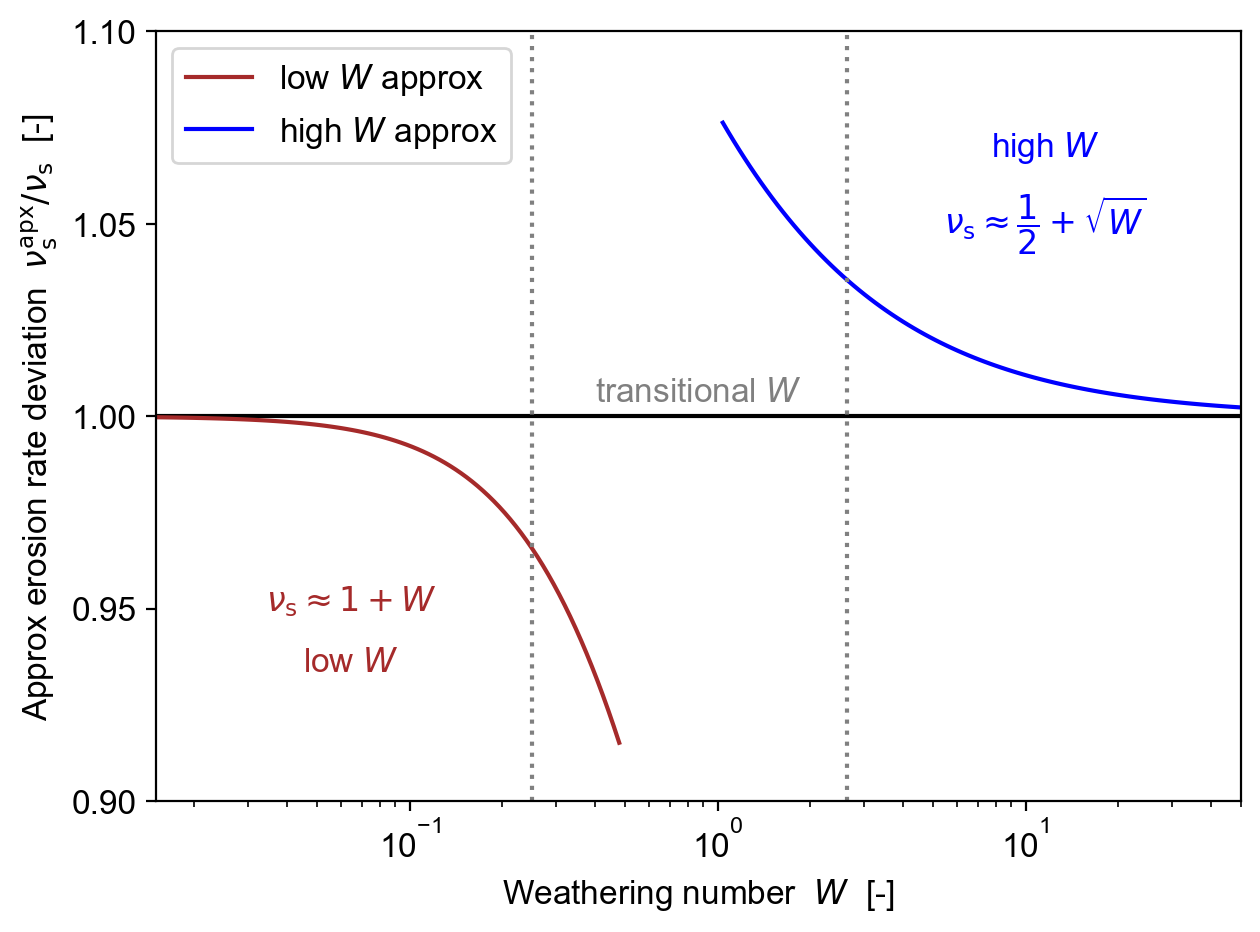

In [24]:
fig_nu_s_approx_devn = wmbe.plot.create_figure("nu_s_approx_devn")
wmbe.plot.plot_nus_W_transition(fig_nu_s, em)

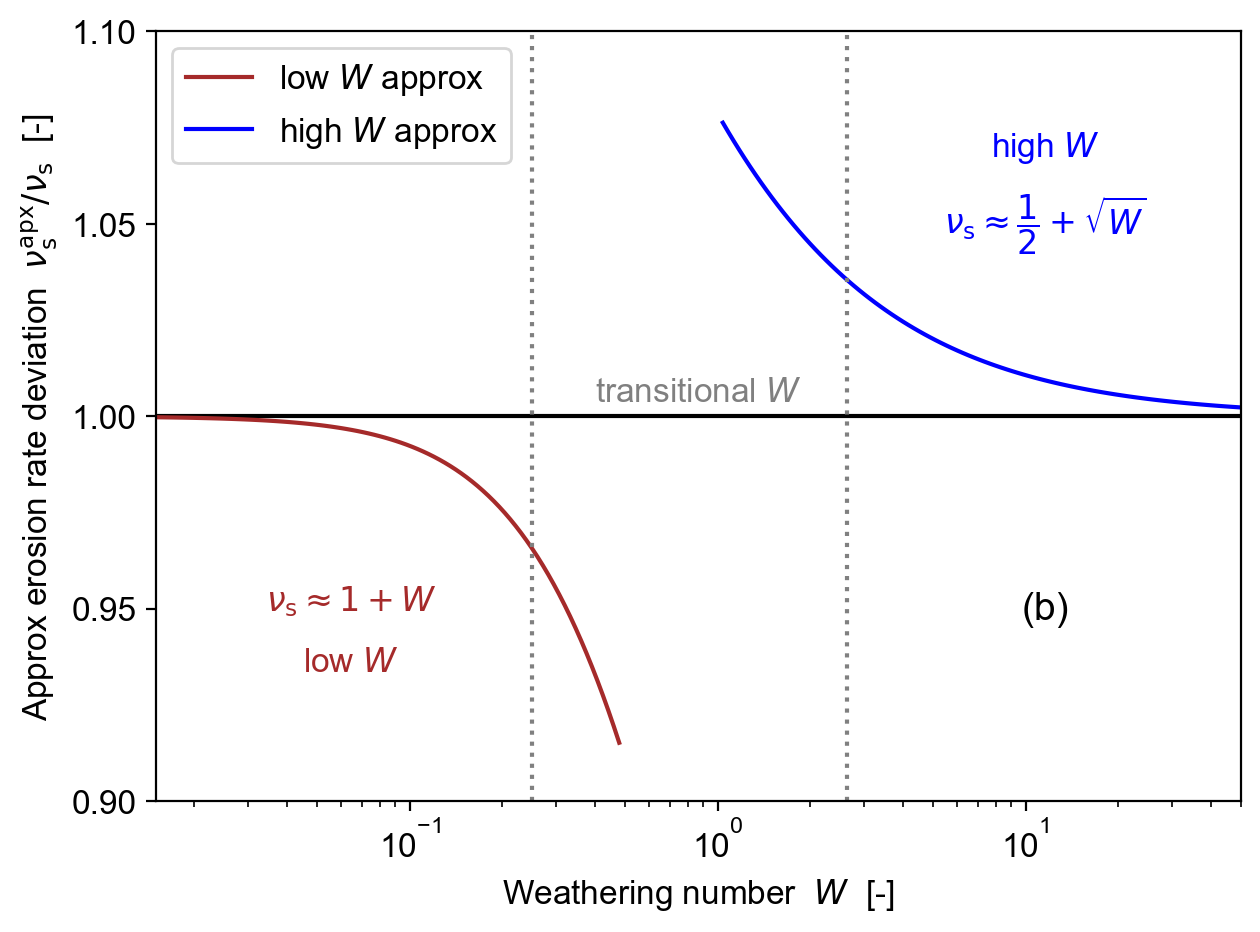

In [25]:
fig_nu_s_approx_devn_subfigb \
    = wmbe.plot.create_figure("nu_s_approx_devn_subfigb")
wmbe.plot.plot_nus_W_transition(fig_nu_s, em, text_label="(b)")


## Save

In [26]:
results_dir = wmbe.save.create_plots_dir()

In [27]:
wmbe.save.export_plots(wmbe.plot.fdict,results_dir,"pdf")

Exported "highW_nu_evolution.pdf"
Exported "highW_eta_evolution.pdf"
Exported "highW_eta_evolution_subfigb.pdf"
Exported "highW_etas_ss.pdf"
Exported "highTransW_eta_evolution.pdf"
Exported "lowTransW_nu_evolution.pdf"
Exported "lowTransW_eta_evolution.pdf"
Exported "lowTransW_etas_ss.pdf"
Exported "lowW_nu_evolution.pdf"
Exported "lowW_eta_evolution_subfiga.pdf"
Exported "lowW_etas_ss.pdf"
Exported "etas_setW_ss.pdf"
Exported "nu_s.pdf"
Exported "nu_s_subfiga.pdf"
Exported "nu_s_approx_devn.pdf"
Exported "nu_s_approx_devn_subfigb.pdf"


In [28]:
fig = "highW_eta_evolution"
wmbe.save.export_plots({fig:wmbe.plot.fdict.get(fig)},results_dir,"png")
fig = "nu_s"
wmbe.save.export_plots({fig:wmbe.plot.fdict.get(fig)},results_dir,"png")

Exported "highW_eta_evolution.png"
Exported "nu_s.png"
